# 05 — Artist-catalog attention and Last.fm

**Purpose.** Estimate the artist-catalog attention analyses (static, dynamic, matched, and
robustness) on songs never linked to films, and the Last.fm cumulative listener-reach
diagnostics. Separate prior attention differences from changes in other Billboard songs
by the same artists. The matched changes do not establish corresponding increases across
this observed repertoire.

**Inputs.** `outputs/data/spotify_song_snapshot_panel.csv`, `outputs/data/lastfm_song_panel.csv`,
`outputs/data/master_song_panel.csv` (notebook 01).

**Outputs (result objects).** `results/catalog_static.csv`, `results/catalog_dynamic.csv`,
`results/catalog_dynamic_support.csv`, `results/catalog_matching_estimates.csv`,
`results/catalog_matching_balance_long.csv`, `results/catalog_matching_inference.csv`,
`results/robustness_cluster_rows.csv`, `results/lastfm_age_profile.csv`, and the SI figure
`figure_si_lastfm_age_profile.pdf`.

**Unit of analysis.** Non-film Billboard song-snapshots (Spotify) and non-film song records
(Last.fm). Catalog exposure: the same normalized artist/band string has another Billboard song
linked to a film.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw_checksums.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display

from cdr import paths, build, util
from cdr.util import SNAPSHOTS, SNAPSHOT_LABEL, check, show_and_save_table, show_and_save_figure

paths.ensure_output_dirs()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
RESULTS = paths.RESULTS

In [2]:
from cdr import temporal as tmp
from cdr.matching import nearest_neighbor_match, summarize_pairs, replacement_aware_inference, cem_estimate

panel = pd.read_csv(paths.OUT_DATA / "spotify_song_snapshot_panel.csv", low_memory=False)
lastfm = pd.read_csv(paths.OUT_DATA / "lastfm_song_panel.csv", low_memory=False)
master = pd.read_csv(paths.OUT_DATA / "master_song_panel.csv", low_memory=False)
nonfilm = panel[panel["film_linked"].eq(0)].copy()
print(f"Non-film song-snapshots: {len(nonfilm):,} | catalog-exposed: {int(nonfilm['artist_has_treated_song'].sum()):,}")

Non-film song-snapshots: 66,838 | catalog-exposed: 35,138


## Static artist-catalog regressions

Exact final specification (per snapshot and pooled with snapshot fixed effects, HC1; the
pooled model also stores cluster-by-song inference):

`attention ~ artist_has_treated_song + age + age^2 + weeks + peak_pos + artist_billboard_songs + artist_total_weeks_excl_song + artist_best_peak_excl_song + artist_superstar_top1pct`

restricted to songs never linked to films. Artists with single-song catalogs drop out through
the best-other-peak covariate. The Last.fm model uses the same specification with log1p
cumulative listeners.

In [3]:
CATALOG_FORMULA = ("attention ~ artist_has_treated_song + age + I(age**2) + weeks + peak_pos + "
                   "artist_billboard_songs + artist_total_weeks_excl_song + artist_best_peak_excl_song + artist_superstar_top1pct")
CATALOG_COVS_NEEDED = ["attention", "artist_has_treated_song", "age", "weeks", "peak_pos",
                       "artist_billboard_songs", "artist_total_weeks_excl_song", "artist_best_peak_excl_song"]

static_rows = []
d_all = nonfilm.dropna(subset=CATALOG_COVS_NEEDED).copy()
for snapshot, d in d_all.groupby("snapshot"):
    mod = smf.ols(CATALOG_FORMULA, data=d).fit(cov_type="HC1")
    est, se, lo, hi, p = util.ci_from_model(mod, "artist_has_treated_song")
    static_rows.append({"platform": "Spotify", "snapshot": snapshot, "estimate": est, "std_error": se,
                        "conf_low": lo, "conf_high": hi, "p_value": p, "n_song_snapshots": int(mod.nobs),
                        "n_exposed": int(d["artist_has_treated_song"].sum()), "n_control": int((d["artist_has_treated_song"] == 0).sum())})
mod_pooled = smf.ols(CATALOG_FORMULA + " + C(snapshot)", data=d_all).fit(cov_type="HC1")
mod_pooled_cl = smf.ols(CATALOG_FORMULA + " + C(snapshot)", data=d_all).fit(cov_type="cluster", cov_kwds={"groups": d_all["song_artist_id"]})
est, se, lo, hi, p = util.ci_from_model(mod_pooled, "artist_has_treated_song")
static_rows.append({"platform": "Spotify", "snapshot": "pooled", "estimate": est, "std_error": se,
                    "conf_low": lo, "conf_high": hi, "p_value": p, "n_song_snapshots": int(mod_pooled.nobs),
                    "n_exposed": int(d_all["artist_has_treated_song"].sum()), "n_control": int((d_all["artist_has_treated_song"] == 0).sum())})

d_lfm = lastfm[lastfm["film_linked"].eq(0)].dropna(subset=CATALOG_COVS_NEEDED).copy()
mod_lfm = smf.ols(CATALOG_FORMULA, data=d_lfm).fit(cov_type="HC1")
est, se, lo, hi, p = util.ci_from_model(mod_lfm, "artist_has_treated_song")
static_rows.append({"platform": "Last.fm", "snapshot": "2017-07", "estimate": est, "std_error": se,
                    "conf_low": lo, "conf_high": hi, "p_value": p, "n_song_snapshots": int(mod_lfm.nobs),
                    "n_exposed": int(d_lfm["artist_has_treated_song"].sum()), "n_control": int((d_lfm["artist_has_treated_song"] == 0).sum())})
catalog_static = pd.DataFrame(static_rows)
show_and_save_table(catalog_static.round(4), RESULTS / "catalog_static.csv")

pooled_est = catalog_static.loc[catalog_static["snapshot"].eq("pooled"), "estimate"].iloc[0]
check(abs(pooled_est - 2.4684) < 0.01, "pooled adjusted catalog premium = 2.47")
check(abs(catalog_static.loc[catalog_static["snapshot"].eq("2025"), "estimate"].iloc[0] - 2.3413) < 0.01, "August 2025 adjusted catalog premium = 2.34")
check((catalog_static.loc[catalog_static["platform"].eq("Spotify") & catalog_static["snapshot"].ne("pooled"), "estimate"] > 0).all(), "catalog premium is positive in every Spotify snapshot")
check(catalog_static.loc[catalog_static["platform"].eq("Last.fm"), "estimate"].iloc[0] > 0, "Last.fm catalog premium is positive")

,platform,snapshot,estimate,std_error,conf_low,conf_high,p_value,n_song_snapshots,n_exposed,n_control
0,Spotify,2016-10,2.3202,0.2594,1.8117,2.8286,0.0,10966,6858,4108
1,Spotify,2017-07,3.5682,0.2668,3.0454,4.0911,0.0,12550,8253,4297
2,Spotify,2022-08,2.0804,0.2487,1.5930,2.5677,0.0,15487,9356,6131
3,Spotify,2025,2.3413,0.2268,1.8966,2.7859,0.0,18442,10671,7771
4,Spotify,pooled,2.4684,0.1261,2.2213,2.7155,0.0,57445,35138,22307
5,Last.fm,2017-07,0.6750,0.0401,0.5964,0.7536,0.0,12419,8179,4240


PASS: pooled adjusted catalog premium = 2.47
PASS: August 2025 adjusted catalog premium = 2.34
PASS: catalog premium is positive in every Spotify snapshot
PASS: Last.fm catalog premium is positive


## Dynamic artist-catalog event-time pattern

Event time is measured relative to the first film appearance of **any other Billboard song by
the same artist**; non-film songs by artists with no film-linked song form the omitted `-1`
reference together with the immediate pre-year. A positive pre-event bin (`<= -2`) is
evidence of attention differences that predate placement. The dynamic coefficients
do not isolate increases associated with film placement.

In [4]:
artist_first = (
    master[master["film_linked"].eq(1) & master["first_year"].notna()]
    .groupby("artist_key_alnum")["first_year"].min().rename("artist_first_film_year").reset_index()
)
d_dyn = nonfilm.merge(artist_first, on="artist_key_alnum", how="left")
d_dyn["catalog_rel_time"] = d_dyn["snapshot_year"] - d_dyn["artist_first_film_year"]
d_dyn["catalog_event_bin"] = tmp.event_bins(d_dyn["catalog_rel_time"])
d_dyn.loc[d_dyn["artist_first_film_year"].isna(), "catalog_event_bin"] = "-1"
d_dyn = d_dyn[d_dyn["catalog_event_bin"].isin(["<= -2", "-1", "0", "1 to 5", ">5"])]
d_dyn = d_dyn.dropna(subset=["attention", "age", "weeks", "peak_pos"])
mod_dyn = smf.ols("attention ~ C(catalog_event_bin, Treatment(reference='-1')) + age + I(age**2) + weeks + peak_pos + C(snapshot)", data=d_dyn).fit(cov_type="HC1")
dyn_rows = []
for b, lab in [("<= -2", "pre (<= -2 years)"), ("0", "event year"), ("1 to 5", "1-5 years post"), (">5", ">5 years post")]:
    term = f"C(catalog_event_bin, Treatment(reference='-1'))[T.{b}]"
    est, se, lo, hi, p = util.ci_from_model(mod_dyn, term)
    dyn_rows.append({"term": lab, "estimate": est, "std_error": se, "conf_low": lo, "conf_high": hi, "p_value": p, "n_song_snapshots": int(mod_dyn.nobs)})
catalog_dynamic = pd.DataFrame(dyn_rows)
show_and_save_table(catalog_dynamic.round(4), RESULTS / "catalog_dynamic.csv")
dyn_support = (
    d_dyn[d_dyn["catalog_event_bin"].ne("-1")].groupby("catalog_event_bin")
    .agg(n_song_snapshots=("attention", "size"), n_songs=("song_artist_id", "nunique"), n_artists=("artist_key_alnum", "nunique"))
    .reset_index()
)
show_and_save_table(dyn_support, RESULTS / "catalog_dynamic_support.csv")
check(int(mod_dyn.nobs) == 66838, "dynamic catalog model uses 66,838 song-snapshot observations")
check(abs(catalog_dynamic.loc[catalog_dynamic["term"].str.startswith("pre"), "estimate"].iloc[0] - 5.3139) < 0.01, "pre-event catalog bin = 5.31 (selection)")

,term,estimate,std_error,conf_low,conf_high,p_value,n_song_snapshots
0,pre (<= -2 years),5.3139,0.5125,4.3094,6.3185,0.0,66838
1,event year,5.0882,0.7406,3.6366,6.5399,0.0,66838
2,1-5 years post,5.3989,0.2536,4.9019,5.8959,0.0,66838
3,>5 years post,3.6646,0.1051,3.4587,3.8705,0.0,66838


,catalog_event_bin,n_song_snapshots,n_songs,n_artists
0,0,211,210,43
1,1 to 5,1776,1292,171
2,<= -2,407,233,38
3,>5,32506,10274,1525


PASS: dynamic catalog model uses 66,838 song-snapshot observations
PASS: pre-event catalog bin = 5.31 (selection)


## Matched artist-catalog comparisons

Among non-film songs, catalog-exposed songs are matched with replacement to songs by artists
with no film-linked Billboard song. Historical matching balances chart year, age, weeks, peak
position, and artist-level historical covariates; prior-attention matching additionally
balances the previous snapshot's Spotify popularity with a five-point caliper. Pooled rows
aggregate the per-snapshot matched differences by inverse variance (descriptive).

In [5]:
CAT_MATCH_COVS = ["chart_year", "age", "weeks", "peak_pos", "artist_billboard_songs",
                  "artist_total_weeks_excl_song", "artist_mean_weeks_excl_song",
                  "artist_best_peak_excl_song", "artist_superstar_top1pct"]

summary_rows, balance_rows, pair_store = [], [], {}
for snapshot, g in nonfilm.groupby("snapshot"):
    d = g.copy()
    d["catalog_exposed"] = d["artist_has_treated_song"].astype(int)
    for design, covs, cal_col, cal in [
        ("catalog historical + artist-success NN", CAT_MATCH_COVS, None, None),
        ("catalog baseline-attention + artist-success NN", CAT_MATCH_COVS + ["previous_popularity"], "previous_popularity", 5.0),
    ]:
        if design.startswith("catalog baseline") and snapshot == "2016-10":
            continue
        dd = d.dropna(subset=["attention", "catalog_exposed"]).copy()
        if cal_col:
            dd = dd[dd[cal_col].notna()].copy()
        pairs, balance = nearest_neighbor_match(dd, "catalog_exposed", covs, caliper_col=cal_col, caliper=cal)
        row = summarize_pairs(pairs, balance, design, snapshot, int(dd["catalog_exposed"].eq(1).sum()), int(dd["catalog_exposed"].eq(0).sum()))
        row["platform"] = "Spotify"
        summary_rows.append(row)
        balance["design"], balance["snapshot"], balance["platform"] = design, snapshot, "Spotify"
        balance_rows.append(balance)
        pair_store[(design, snapshot)] = pairs

import math
sp = pd.DataFrame(summary_rows)
for design, g in sp.groupby("design"):
    valid = g.dropna(subset=["estimate", "std_error"])
    if len(valid) and (valid["std_error"] > 0).all():
        w = 1 / (valid["std_error"] ** 2)
        est = float((valid["estimate"] * w).sum() / w.sum())
        se = float(math.sqrt(1 / w.sum()))
        summary_rows.append({"platform": "Spotify", "design": design, "snapshot": "pooled (inverse-variance)",
                             "n_treated_available": int(valid["n_treated_available"].sum()),
                             "n_matched_treated": int(valid["n_matched_treated"].sum()),
                             "n_controls_available": int(valid["n_controls_available"].sum()),
                             "replacement": "with replacement within snapshot", "estimate": est, "std_error": se,
                             "conf_low": est - 1.96 * se, "conf_high": est + 1.96 * se,
                             "max_abs_smd_before": valid["max_abs_smd_before"].max(),
                             "max_abs_smd_after": valid["max_abs_smd_after"].max()})

d_lfm2 = lastfm[lastfm["film_linked"].eq(0)].copy()
d_lfm2["catalog_exposed"] = d_lfm2["artist_has_treated_song"].astype(int)
dd = d_lfm2.dropna(subset=["attention", "catalog_exposed", "previous_popularity"]).copy()
pairs_lfm, bal_lfm = nearest_neighbor_match(dd, "catalog_exposed", CAT_MATCH_COVS + ["previous_popularity"], caliper_col="previous_popularity", caliper=5.0)
row = summarize_pairs(pairs_lfm, bal_lfm, "catalog baseline-attention + artist-success NN", "2017-07", int(dd["catalog_exposed"].eq(1).sum()), int(dd["catalog_exposed"].eq(0).sum()))
row["platform"] = "Last.fm"
summary_rows.append(row)
bal_lfm["design"], bal_lfm["snapshot"], bal_lfm["platform"] = "catalog baseline-attention + artist-success NN", "2017-07", "Last.fm"
balance_rows.append(bal_lfm)

catalog_matching = pd.DataFrame(summary_rows)
catalog_balance = pd.concat(balance_rows, ignore_index=True)
catalog_balance["family"] = "artist-catalog matching"
show_and_save_table(catalog_matching.round(4), RESULTS / "catalog_matching_estimates.csv")
show_and_save_table(catalog_balance.round(4), RESULTS / "catalog_matching_balance_long.csv", max_rows=12)

pooled_prior = catalog_matching[(catalog_matching["snapshot"].eq("pooled (inverse-variance)")) & (catalog_matching["design"].str.contains("baseline"))]["estimate"].iloc[0]
print(f"Pooled baseline-attention matched catalog premium: {pooled_prior:.3f}")
check(abs(pooled_prior - 0.306) < 0.01, "pooled baseline-attention matched catalog premium = 0.31 points")
hist_rows = catalog_matching[(catalog_matching["platform"].eq("Spotify")) & (catalog_matching["design"].str.startswith("catalog historical")) & (~catalog_matching["snapshot"].str.startswith("pooled"))]
check((hist_rows["estimate"] > 0).all(), "historical matched catalog premium is positive in every snapshot")

,design,snapshot,n_treated_available,n_matched_treated,n_unique_controls,n_controls_available,replacement,estimate,std_error,conf_low,conf_high,p_value,max_abs_smd_before,max_abs_smd_after,platform
0,catalog historical + artist-success NN,2016-10,6858,6858,1997.0,6664,with replacement,2.4940,0.1836,2.1341,2.8539,0.0000,1.0744,0.1251,Spotify
1,catalog historical + artist-success NN,2017-07,8253,8253,2201.0,5803,with replacement,2.8900,0.1803,2.5366,3.2434,0.0000,0.9739,0.1592,Spotify
2,catalog baseline-attention + artist-success NN,2017-07,6794,6794,1927.0,4621,with replacement,0.4570,0.0866,0.2873,0.6268,0.0000,0.9591,0.1634,Spotify
3,catalog historical + artist-success NN,2022-08,9356,9356,2932.0,8376,with replacement,1.3803,0.1851,1.0175,1.7431,0.0000,0.8788,0.1544,Spotify
4,catalog baseline-attention + artist-success NN,2022-08,7712,7712,2197.0,5325,with replacement,-0.3090,0.1310,-0.5657,-0.0523,0.0183,0.9685,0.2008,Spotify
5,catalog historical + artist-success NN,2025,10671,10671,3435.0,10857,with replacement,1.4564,0.1713,1.1206,1.7921,0.0000,0.8665,0.1784,Spotify
6,catalog baseline-attention + artist-success NN,2025,9285,9285,3050.0,7961,with replacement,0.4389,0.0915,0.2596,0.6182,0.0000,0.8633,0.1682,Spotify
7,catalog baseline-attention + artist-success NN,pooled (inverse-variance),23791,23791,NaN,17907,with replacement within snapshot,0.3065,0.0567,0.1954,0.4176,NaN,0.9685,0.2008,Spotify
8,catalog historical + artist-success NN,pooled (inverse-variance),35138,35138,NaN,31700,with replacement within snapshot,2.0438,0.0899,1.8675,2.2200,NaN,1.0744,0.1784,Spotify
9,catalog baseline-attention + artist-success NN,2017-07,6727,6727,1892.0,4548,with replacement,0.2928,0.0212,0.2513,0.3344,0.0000,0.9578,0.1646,Last.fm


,covariate,treated_mean_before,control_mean_before,smd_before,treated_mean_after,control_mean_after,smd_after,design,snapshot,platform,family
0,chart_year,1983.1710,1990.1973,-0.3907,1983.1710,1983.1880,-0.0010,catalog historical + artist-success NN,2016-10,Spotify,artist-catalog matching
1,age,33.6290,26.6027,0.3907,33.6290,33.6120,0.0010,catalog historical + artist-success NN,2016-10,Spotify,artist-catalog matching
2,weeks,11.2003,12.0614,-0.1083,11.2003,11.1372,0.0087,catalog historical + artist-success NN,2016-10,Spotify,artist-catalog matching
3,peak_pos,44.9711,47.3777,-0.0813,44.9711,44.6521,0.0111,catalog historical + artist-success NN,2016-10,Spotify,artist-catalog matching
4,artist_billboard_songs,20.4930,10.0056,0.4506,20.4930,18.5490,0.1208,catalog historical + artist-success NN,2016-10,Spotify,artist-catalog matching
5,artist_total_weeks_excl_song,222.5066,60.0165,1.0744,222.5066,201.0949,0.1251,catalog historical + artist-success NN,2016-10,Spotify,artist-catalog matching
6,artist_mean_weeks_excl_song,12.2047,10.6427,0.2871,12.2047,12.1754,0.0064,catalog historical + artist-success NN,2016-10,Spotify,artist-catalog matching
7,artist_best_peak_excl_song,6.9503,26.0166,-0.9221,6.9503,7.3155,-0.0314,catalog historical + artist-success NN,2016-10,Spotify,artist-catalog matching
8,artist_superstar_top1pct,0.2263,0.0506,0.5261,0.2263,0.2260,0.0007,catalog historical + artist-success NN,2016-10,Spotify,artist-catalog matching
9,chart_year,1982.5722,1986.5494,-0.2232,1982.5722,1982.6808,-0.0064,catalog historical + artist-success NN,2017-07,Spotify,artist-catalog matching


Pooled baseline-attention matched catalog premium: 0.306
PASS: pooled baseline-attention matched catalog premium = 0.31 points
PASS: historical matched catalog premium is positive in every snapshot


### Replacement-aware catalog inference

Catalog controls are reused heavily, so the cluster-by-control bootstrap is the primary
uncertainty check for the prior-attention matched catalog premium; no-replacement,
stricter-caliper, and coarsened-exact-matching variants are design sensitivities.

In [6]:
rng = np.random.default_rng(20260603)
inf_rows = []
for snapshot in ["2017-07", "2022-08", "2025"]:
    pairs = pair_store[("catalog baseline-attention + artist-success NN", snapshot)].copy()
    pairs["control_key"] = pairs["control_song_artist_id"]
    r = replacement_aware_inference(pairs, f"catalog baseline-attention | {snapshot} (with replacement)", rng)
    r.update({"design": "catalog baseline-attention + artist-success NN", "snapshot": snapshot, "variant": "with replacement"})
    inf_rows.append(r)
    d = nonfilm[nonfilm["snapshot"].eq(snapshot)].copy()
    d["catalog_exposed"] = d["artist_has_treated_song"].astype(int)
    dd = d.dropna(subset=["attention", "catalog_exposed", "previous_popularity"]).copy()
    pr_nr, _ = nearest_neighbor_match(dd, "catalog_exposed", CAT_MATCH_COVS + ["previous_popularity"], caliper_col="previous_popularity", caliper=5.0, replace=False, max_candidates=60)
    if not pr_nr.empty:
        e, se, lo, hi, p = util.ci_mean(pr_nr["diff"])
        inf_rows.append({"comparison": f"catalog baseline-attention | {snapshot} (no replacement)", "design": "catalog baseline-attention + artist-success NN",
                         "snapshot": snapshot, "variant": "no replacement", "n_matched_pairs": len(pr_nr),
                         "n_unique_controls": int(pr_nr["control_song_artist_id"].nunique()), "control_reuse_share": 0.0,
                         "estimate": float(e), "naive_paired_se": float(se), "naive_ci_low": lo, "naive_ci_high": hi})
    pr_cal, _ = nearest_neighbor_match(dd, "catalog_exposed", CAT_MATCH_COVS + ["previous_popularity"], caliper_col="previous_popularity", caliper=2.0)
    e, se, lo, hi, p = util.ci_mean(pr_cal["diff"])
    inf_rows.append({"comparison": f"catalog baseline-attention | {snapshot} (stricter caliper 2.0)", "design": "catalog baseline-attention + artist-success NN",
                     "snapshot": snapshot, "variant": "stricter caliper", "n_matched_pairs": len(pr_cal),
                     "n_unique_controls": int(pr_cal["control_song_artist_id"].nunique()),
                     "control_reuse_share": float(1 - pr_cal["control_song_artist_id"].nunique() / len(pr_cal)),
                     "estimate": float(e), "naive_paired_se": float(se), "naive_ci_low": lo, "naive_ci_high": hi})
    cem, n_cem = cem_estimate(dd, "catalog_exposed")
    inf_rows.append({"comparison": f"catalog baseline-attention | {snapshot} (CEM decade x baseline-pop quintile)", "design": "catalog baseline-attention + artist-success NN",
                     "snapshot": snapshot, "variant": "CEM", "n_matched_pairs": n_cem, "estimate": cem})
catalog_inference = pd.DataFrame(inf_rows)
show_and_save_table(catalog_inference.round(4), RESULTS / "catalog_matching_inference.csv")
wr = catalog_inference[catalog_inference["variant"].eq("with replacement")]
qualified = wr[(wr["cluster_control_ci_low"] < 0) & (wr["cluster_control_ci_high"] > 0)]
print(f"Snapshots whose cluster-by-control interval crosses zero: {qualified['snapshot'].tolist()}")
check((wr["cluster_control_se"] > wr["naive_paired_se"]).all(), "cluster-by-control SEs exceed naive paired SEs (reuse matters for catalog inference)")

,comparison,n_matched_pairs,n_unique_controls,control_reuse_share,estimate,naive_paired_se,naive_ci_low,naive_ci_high,boot_treated_se,boot_treated_ci_low,boot_treated_ci_high,cluster_control_se,cluster_control_ci_low,cluster_control_ci_high,design,snapshot,variant
0,catalog baseline-attention | 2017-07 (with rep...,6794,1927.0,0.7164,0.4570,0.0866,0.2873,0.6268,0.0893,0.2698,0.6508,0.1745,0.1144,0.7933,catalog baseline-attention + artist-success NN,2017-07,with replacement
1,catalog baseline-attention | 2017-07 (no repla...,3271,3271.0,0.0000,1.2947,0.1304,1.0390,1.5504,NaN,NaN,NaN,NaN,NaN,NaN,catalog baseline-attention + artist-success NN,2017-07,no replacement
2,catalog baseline-attention | 2017-07 (stricter...,6794,2019.0,0.7028,0.2620,0.0813,0.1026,0.4214,NaN,NaN,NaN,NaN,NaN,NaN,catalog baseline-attention + artist-success NN,2017-07,stricter caliper
3,catalog baseline-attention | 2017-07 (CEM deca...,6794,NaN,NaN,1.5699,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,catalog baseline-attention + artist-success NN,2017-07,CEM
4,catalog baseline-attention | 2022-08 (with rep...,7712,2197.0,0.7151,-0.3090,0.1310,-0.5657,-0.0523,0.1298,-0.5592,-0.0669,0.3166,-0.9702,0.2569,catalog baseline-attention + artist-success NN,2022-08,with replacement
5,catalog baseline-attention | 2022-08 (no repla...,3740,3740.0,0.0000,0.3166,0.1828,-0.0416,0.6748,NaN,NaN,NaN,NaN,NaN,NaN,catalog baseline-attention + artist-success NN,2022-08,no replacement
6,catalog baseline-attention | 2022-08 (stricter...,7712,2293.0,0.7027,-0.3463,0.1271,-0.5955,-0.0972,NaN,NaN,NaN,NaN,NaN,NaN,catalog baseline-attention + artist-success NN,2022-08,stricter caliper
7,catalog baseline-attention | 2022-08 (CEM deca...,7712,NaN,NaN,-0.6993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,catalog baseline-attention + artist-success NN,2022-08,CEM
8,catalog baseline-attention | 2025 (with replac...,9285,3049.0,0.6716,0.4389,0.0915,0.2596,0.6182,0.0889,0.2562,0.6090,0.1839,0.0896,0.8138,catalog baseline-attention + artist-success NN,2025,with replacement
9,catalog baseline-attention | 2025 (no replacem...,5268,5265.0,0.0000,1.0243,0.1239,0.7815,1.2670,NaN,NaN,NaN,NaN,NaN,NaN,catalog baseline-attention + artist-success NN,2025,no replacement


Snapshots whose cluster-by-control interval crosses zero: ['2022-08']
PASS: cluster-by-control SEs exceed naive paired SEs (reuse matters for catalog inference)



## Matched catalog attention changes on the fixed matched pairs

The prior-attention matched catalog design above compares post-level attention between
catalog-exposed and unexposed non-film songs. To compare attention changes, the same fixed pairs are re-expressed as prior-to-current changes: for each
matched pair, treated change minus control change (difference-in-change). No rematching is
performed; the pair sets are exactly the stored pair objects from the matched design above,
so artist identity semantics, the catalog exposure definition, the treated and control
pools, the matching covariates, the five-point prior-attention caliper, matching with
replacement, the cohort definitions, and the snapshot support are preserved by construction.
Before the attention changes are computed, the pair support and post-level premiums are
re-validated against the stored matched-design estimates. These changes do not measure
audience retention, survival, or duration of attention.

Because catalog exposure is defined at the artist level, matched pairs are dependent within
artist identities: multiple Billboard songs can belong to the same treated artist, control
songs are reused under matching with replacement, and multiple control songs can belong to
the same control artist. The primary uncertainty calculation is therefore a two-way
pigeonhole bootstrap over treated artist identity x control artist identity, which
independently resamples both artist-cluster dimensions and reweights pairs by the product
of the corresponding cluster draw counts (2,000 deterministic-seed replications). The naive
paired standard error, a block bootstrap over treated artist identities, and a cluster
bootstrap over reused control artist identities are reported alongside it. The treated and
control artist-cluster sets are disjoint (catalog-exposed versus unexposed artists), so the
two resampling dimensions are well posed. Pair-level rows are never treated as independent
observations for primary inference.


In [7]:
RETENTION_COHORTS = ["2017-07", "2022-08", "2025"]
retention_frames = []
for snapshot in RETENTION_COHORTS:
    pairs = pair_store[("catalog baseline-attention + artist-success NN", snapshot)]
    prior = (nonfilm[nonfilm["snapshot"].eq(snapshot)]
             .drop_duplicates("song_artist_id").set_index("song_artist_id")["previous_popularity"])
    pf = pd.DataFrame({
        "cohort": snapshot,
        "treated_song_id": pairs["treated_song_artist_id"].to_numpy(),
        "treated_artist_id": pairs["treated_artist_key"].to_numpy(),
        "control_song_id": pairs["control_song_artist_id"].to_numpy(),
        "control_artist_id": pairs["control_artist_key"].to_numpy(),
        "treated_current": pairs["treated_outcome"].to_numpy(float),
        "control_current": pairs["control_outcome"].to_numpy(float),
        "match_distance": pairs["match_distance"].to_numpy(float),
    })
    pf["treated_prior"] = pf["treated_song_id"].map(prior).astype(float)
    pf["control_prior"] = pf["control_song_id"].map(prior).astype(float)
    pf["treated_change"] = pf["treated_current"] - pf["treated_prior"]
    pf["control_change"] = pf["control_current"] - pf["control_prior"]
    pf["difference_in_change"] = pf["treated_change"] - pf["control_change"]
    retention_frames.append(pf)

retention_pairs = pd.concat(retention_frames, ignore_index=True)[[
    "cohort", "treated_song_id", "treated_artist_id", "control_song_id", "control_artist_id",
    "treated_prior", "treated_current", "control_prior", "control_current",
    "treated_change", "control_change", "difference_in_change", "match_distance"]]

identity_error = (retention_pairs["difference_in_change"]
                  - ((retention_pairs["treated_current"] - retention_pairs["control_current"])
                     - (retention_pairs["treated_prior"] - retention_pairs["control_prior"]))).abs().max()
check(identity_error < 1e-12, "difference-in-change equals (current gap) minus (prior gap) exactly")
check(retention_pairs[["treated_prior", "control_prior"]].notna().all().all(),
      "every pair in the baseline-attention design has observed prior attention on both sides")

EXPECTED_PAIRS = {"2017-07": 6794, "2022-08": 7712, "2025": 9285}
EXPECTED_PREMIUM = {"2017-07": 0.457, "2022-08": -0.309, "2025": 0.439}
for snapshot in RETENTION_COHORTS:
    g = retention_pairs[retention_pairs["cohort"].eq(snapshot)]
    stored = catalog_matching[(catalog_matching["platform"].eq("Spotify"))
                              & (catalog_matching["design"].str.startswith("catalog baseline-attention"))
                              & (catalog_matching["snapshot"].eq(snapshot))].iloc[0]
    post_premium = float((g["treated_current"] - g["control_current"]).mean())
    check(len(g) == EXPECTED_PAIRS[snapshot], f"{snapshot}: exact matched pair support ({EXPECTED_PAIRS[snapshot]:,})")
    check(len(g) == int(stored["n_matched_treated"]), f"{snapshot}: pair count equals the stored matched-design support")
    check(abs(post_premium - float(stored["estimate"])) < 1e-9, f"{snapshot}: post-level premium equals the stored matched estimate")
    check(abs(post_premium - EXPECTED_PREMIUM[snapshot]) < 0.01, f"{snapshot}: matched catalog premium reproduces the reported value ({EXPECTED_PREMIUM[snapshot]:+.2f})")

show_and_save_table(retention_pairs.round(4), RESULTS / "catalog_retention_pairs.csv", max_rows=10)
print(f"Retention pair rows: {len(retention_pairs):,} | identity max error: {identity_error:.3g}")


PASS: difference-in-change equals (current gap) minus (prior gap) exactly
PASS: every pair in the baseline-attention design has observed prior attention on both sides
PASS: 2017-07: exact matched pair support (6,794)
PASS: 2017-07: pair count equals the stored matched-design support
PASS: 2017-07: post-level premium equals the stored matched estimate
PASS: 2017-07: matched catalog premium reproduces the reported value (+0.46)
PASS: 2022-08: exact matched pair support (7,712)
PASS: 2022-08: pair count equals the stored matched-design support
PASS: 2022-08: post-level premium equals the stored matched estimate
PASS: 2022-08: matched catalog premium reproduces the reported value (-0.31)
PASS: 2025: exact matched pair support (9,285)
PASS: 2025: pair count equals the stored matched-design support
PASS: 2025: post-level premium equals the stored matched estimate
PASS: 2025: matched catalog premium reproduces the reported value (+0.44)


,cohort,treated_song_id,treated_artist_id,control_song_id,control_artist_id,treated_prior,treated_current,control_prior,control_current,treated_change,control_change,difference_in_change,match_distance
0,2017-07,65loveaffair||pauldavis,paul davis,ivegotloveonmymind||nataliecole,natalie cole,29.0,34.0,27.0,32.0,5.0,5.0,0.0,0.5738
1,2017-07,tilmybabycomeshome||luthervandross,luther vandross,touchmewhenweredancing||carpenters,carpenters,23.0,28.0,24.0,31.0,5.0,7.0,-2.0,0.7774
2,2017-07,tilsummercomesaround||keithurban,keith urban,welcometothefuture||bradpaisley,brad paisley,39.0,45.0,40.0,45.0,6.0,5.0,1.0,1.0871
3,2017-07,tilyoudomeright||after7,after 7,theylikeitslow||htown,htown,39.0,46.0,36.0,40.0,7.0,4.0,3.0,0.5434
4,2017-07,tilicanmakeitonmyown||tammywynette,tamm wynette,isanybodygointosanantone||charleypride,charle pride,36.0,22.0,39.0,47.0,-14.0,8.0,-22.0,0.7632
5,2017-07,tilikissedyou||theeverlybrothers,the everl brothers,shotgun||jrwalkertheallstars,jr walker the all stars,38.0,42.0,42.0,49.0,4.0,7.0,-3.0,0.9614
6,2017-07,allofasuddenmyheartsings||melcarter,mel carter,itakewhatiwant||jamesbobbypurify,james bobb purify,10.0,13.0,9.0,11.0,3.0,2.0,1.0,0.3644
7,2017-07,allofasuddenmyheartsings||paulanka,paul anka,keeperofthecastle||fourtops,four tops,12.0,16.0,10.0,15.0,4.0,5.0,-1.0,1.3176
8,2017-07,babyhullygully||theolympics,the olympics,formeandmygal||freddycannon,fredd cannon,5.0,6.0,3.0,2.0,1.0,-1.0,2.0,0.4262
9,2017-07,betweenarockandahardplace||cuttingcrew,cutting crew,lookatthatcadillac||straycats,stra cats,15.0,26.0,19.0,23.0,11.0,4.0,7.0,0.5677


Retention pair rows: 23,791 | identity max error: 0


In [8]:
RETENTION_SEED = 20260714
N_BOOT_RETENTION = 2000

def artist_level_retention_inference(g, seed, n_boot=N_BOOT_RETENTION):
    """Naive paired SE plus three replacement-aware bootstraps on the fixed pair set:
    block over treated artist identities, cluster over reused control artist identities,
    and the primary two-way pigeonhole bootstrap over treated x control artist identities."""
    rng = np.random.default_rng(seed)
    diff = g["difference_in_change"].to_numpy(float)
    n = len(diff)
    est = float(diff.mean())
    naive_se = float(diff.std(ddof=1) / np.sqrt(n))
    t_codes = g["treated_artist_id"].astype("category").cat.codes.to_numpy()
    c_codes = g["control_artist_id"].astype("category").cat.codes.to_numpy()
    KT, KC = int(t_codes.max()) + 1, int(c_codes.max()) + 1

    def one_way(codes, K):
        gsum = np.bincount(codes, weights=diff, minlength=K)
        gcnt = np.bincount(codes, minlength=K).astype(float)
        draw = rng.integers(0, K, size=(n_boot, K))
        return gsum[draw].sum(axis=1) / gcnt[draw].sum(axis=1)

    boot_treated_artist = one_way(t_codes, KT)
    boot_control_artist = one_way(c_codes, KC)
    two_way = np.empty(n_boot)
    for b in range(n_boot):
        w_t = np.bincount(rng.integers(0, KT, size=KT), minlength=KT).astype(float)
        w_c = np.bincount(rng.integers(0, KC, size=KC), minlength=KC).astype(float)
        w = w_t[t_codes] * w_c[c_codes]
        sw = w.sum()
        two_way[b] = (w * diff).sum() / sw if sw > 0 else np.nan

    def row(method, draws, se=None, primary="no"):
        if draws is None:
            lo, hi, s = est - 1.96 * se, est + 1.96 * se, se
        else:
            draws = draws[np.isfinite(draws)]
            lo, hi, s = float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5)), float(draws.std(ddof=1))
        return {"cohort": g["cohort"].iloc[0], "method": method, "estimate": est, "se": s,
                "ci_low": lo, "ci_high": hi, "n_pairs": n,
                "n_treated_artists": KT, "n_control_artists": KC,
                "n_bootstrap": (n_boot if draws is not None else np.nan), "primary": primary}

    return [row("naive paired SE", None, se=naive_se),
            row("block bootstrap over treated artist identities", boot_treated_artist),
            row("cluster bootstrap over reused control artist identities", boot_control_artist),
            row("two-way pigeonhole bootstrap (treated x control artist identities)", two_way, primary="yes")]

inference_rows = []
for i, snapshot in enumerate(RETENTION_COHORTS):
    g = retention_pairs[retention_pairs["cohort"].eq(snapshot)]
    inference_rows.extend(artist_level_retention_inference(g, RETENTION_SEED + i))
catalog_retention_inference = pd.DataFrame(inference_rows)

rerun = pd.DataFrame(artist_level_retention_inference(
    retention_pairs[retention_pairs["cohort"].eq(RETENTION_COHORTS[0])], RETENTION_SEED))
first = catalog_retention_inference[catalog_retention_inference["cohort"].eq(RETENTION_COHORTS[0])].reset_index(drop=True)
check(first.equals(rerun), "artist-level bootstrap output is deterministic under the fixed seed")
check(np.isfinite(catalog_retention_inference[["se", "ci_low", "ci_high"]].to_numpy(float)).all(),
      "all artist-level retention intervals are finite")

show_and_save_table(catalog_retention_inference.round(4), RESULTS / "catalog_retention_inference.csv")


PASS: artist-level bootstrap output is deterministic under the fixed seed
PASS: all artist-level retention intervals are finite


,cohort,method,estimate,se,ci_low,ci_high,n_pairs,n_treated_artists,n_control_artists,n_bootstrap,primary
0,2017-07,naive paired SE,0.2726,0.0796,0.1167,0.4285,6794,1293,802,NaN,no
1,2017-07,block bootstrap over treated artist identities,0.2726,0.1182,0.0392,0.5107,6794,1293,802,2000.0,no
2,2017-07,cluster bootstrap over reused control artist i...,0.2726,0.2767,-0.3019,0.7962,6794,1293,802,2000.0,no
3,2017-07,two-way pigeonhole bootstrap (treated x contro...,0.2726,0.3166,-0.3567,0.8895,6794,1293,802,2000.0,yes
4,2022-08,naive paired SE,-0.4769,0.1276,-0.7270,-0.2269,7712,1358,889,NaN,no
5,2022-08,block bootstrap over treated artist identities,-0.4769,0.2170,-0.8980,-0.0504,7712,1358,889,2000.0,no
6,2022-08,cluster bootstrap over reused control artist i...,-0.4769,0.5829,-1.6116,0.6785,7712,1358,889,2000.0,no
7,2022-08,two-way pigeonhole bootstrap (treated x contro...,-0.4769,0.6383,-1.7810,0.7145,7712,1358,889,2000.0,yes
8,2025,naive paired SE,0.3961,0.0880,0.2237,0.5685,9285,1485,1053,NaN,no
9,2025,block bootstrap over treated artist identities,0.3961,0.1597,0.0776,0.6960,9285,1485,1053,2000.0,no


,cohort,method,estimate,se,ci_low,ci_high,n_pairs,n_treated_artists,n_control_artists,n_bootstrap,primary
0,2017-07,naive paired SE,0.2726,0.0796,0.1167,0.4285,6794,1293,802,NaN,no
1,2017-07,block bootstrap over treated artist identities,0.2726,0.1182,0.0392,0.5107,6794,1293,802,2000.0,no
2,2017-07,cluster bootstrap over reused control artist i...,0.2726,0.2767,-0.3019,0.7962,6794,1293,802,2000.0,no
3,2017-07,two-way pigeonhole bootstrap (treated x contro...,0.2726,0.3166,-0.3567,0.8895,6794,1293,802,2000.0,yes
4,2022-08,naive paired SE,-0.4769,0.1276,-0.7270,-0.2269,7712,1358,889,NaN,no
5,2022-08,block bootstrap over treated artist identities,-0.4769,0.2170,-0.8980,-0.0504,7712,1358,889,2000.0,no
6,2022-08,cluster bootstrap over reused control artist i...,-0.4769,0.5829,-1.6116,0.6785,7712,1358,889,2000.0,no
7,2022-08,two-way pigeonhole bootstrap (treated x contro...,-0.4769,0.6383,-1.7810,0.7145,7712,1358,889,2000.0,yes
8,2025,naive paired SE,0.3961,0.0880,0.2237,0.5685,9285,1485,1053,NaN,no
9,2025,block bootstrap over treated artist identities,0.3961,0.1597,0.0776,0.6960,9285,1485,1053,2000.0,no


In [9]:
def classify_retention(row):
    """Mechanical descriptive classification of the cohort change pattern (not based on
    statistical significance): REVERSE if the treated side loses more or gains less;
    REACTIVATION-LIKE if treated attention rises while matched controls do not;
    RETENTION-LIKE if both decline but treated declines less; otherwise NO DIFFERENTIAL
    RETENTION (both sides move together with only a small positive differential)."""
    if row["difference_in_change"] < 0:
        return "REVERSE"
    if row["treated_change"] > 0 and row["control_change"] <= 0:
        return "REACTIVATION-LIKE"
    if row["treated_change"] < 0 and row["control_change"] < 0:
        return "RETENTION-LIKE"
    return "NO DIFFERENTIAL RETENTION"

primary_inf = (catalog_retention_inference[catalog_retention_inference["primary"].eq("yes")]
               .set_index("cohort"))
naive_inf = (catalog_retention_inference[catalog_retention_inference["method"].eq("naive paired SE")]
             .set_index("cohort"))

cohort_rows = []
for snapshot in RETENTION_COHORTS:
    g = retention_pairs[retention_pairs["cohort"].eq(snapshot)]
    p, nv = primary_inf.loc[snapshot], naive_inf.loc[snapshot]
    cohort_rows.append({
        "cohort": snapshot,
        "n_pairs": len(g),
        "n_unique_treated_songs": int(g["treated_song_id"].nunique()),
        "n_unique_control_songs": int(g["control_song_id"].nunique()),
        "n_unique_treated_artists": int(g["treated_artist_id"].nunique()),
        "n_unique_control_artists": int(g["control_artist_id"].nunique()),
        "treated_prior_mean": float(g["treated_prior"].mean()),
        "control_prior_mean": float(g["control_prior"].mean()),
        "treated_current_mean": float(g["treated_current"].mean()),
        "control_current_mean": float(g["control_current"].mean()),
        "treated_change": float(g["treated_change"].mean()),
        "control_change": float(g["control_change"].mean()),
        "difference_in_change": float(g["difference_in_change"].mean()),
        "naive_ci_low": float(nv["ci_low"]), "naive_ci_high": float(nv["ci_high"]),
        "primary_se": float(p["se"]),
        "primary_ci_low": float(p["ci_low"]), "primary_ci_high": float(p["ci_high"]),
    })
catalog_retention_by_cohort = pd.DataFrame(cohort_rows)
catalog_retention_by_cohort["classification"] = catalog_retention_by_cohort.apply(classify_retention, axis=1)
check((catalog_retention_by_cohort["difference_in_change"]
       - catalog_retention_by_cohort["treated_change"]
       + catalog_retention_by_cohort["control_change"]).abs().max() < 1e-12,
      "cohort difference-in-change equals treated change minus control change")
show_and_save_table(catalog_retention_by_cohort.round(4), RESULTS / "catalog_retention_by_cohort.csv")

def fe_pool(df):
    w = 1.0 / (df["primary_se"] ** 2)
    est = float((df["difference_in_change"] * w).sum() / w.sum())
    se = float(np.sqrt(1.0 / w.sum()))
    return est, se

pooled_est, pooled_se = fe_pool(catalog_retention_by_cohort)
q = float((((catalog_retention_by_cohort["difference_in_change"] - pooled_est) ** 2)
           / (catalog_retention_by_cohort["primary_se"] ** 2)).sum())
i2 = float(max(0.0, (q - 2) / q) * 100) if q > 0 else 0.0
catalog_retention_pooled = pd.DataFrame([{
    "summary": "pooled fixed-effect (descriptive)",
    "n_cohorts": 3, "n_pairs": int(catalog_retention_by_cohort["n_pairs"].sum()),
    "difference_in_change": pooled_est, "se": pooled_se,
    "ci_low": pooled_est - 1.96 * pooled_se, "ci_high": pooled_est + 1.96 * pooled_se,
    "cochran_q": q, "i_squared_pct": i2,
    "note": "inverse-variance combination of three heterogeneous cohorts using the primary artist-level variances; descriptive summary only, with only three cohorts the heterogeneity statistics are indicative",
}])
manual_w = 1.0 / (catalog_retention_by_cohort["primary_se"] ** 2)
manual_est = float((catalog_retention_by_cohort["difference_in_change"] * manual_w).sum() / manual_w.sum())
check(abs(manual_est - pooled_est) < 1e-12, "pooled fixed-effect construction verified against a manual recomputation")
show_and_save_table(catalog_retention_pooled.round(4), RESULTS / "catalog_retention_pooled.csv")

loco_rows = []
for omit in RETENTION_COHORTS:
    sub = catalog_retention_by_cohort[~catalog_retention_by_cohort["cohort"].eq(omit)]
    est, se = fe_pool(sub)
    loco_rows.append({"omitted_cohort": omit, "included_cohorts": ", ".join(sub["cohort"]),
                      "difference_in_change": est, "se": se,
                      "ci_low": est - 1.96 * se, "ci_high": est + 1.96 * se})
catalog_retention_leave_one_cohort_out = pd.DataFrame(loco_rows)
show_and_save_table(catalog_retention_leave_one_cohort_out.round(4), RESULTS / "catalog_retention_leave_one_cohort_out.csv")

display(catalog_retention_by_cohort[["cohort", "n_pairs", "treated_change", "control_change",
                                     "difference_in_change", "primary_ci_low", "primary_ci_high",
                                     "classification"]].round(3))
pooled_zero = catalog_retention_pooled["ci_low"].iloc[0] <= 0 <= catalog_retention_pooled["ci_high"].iloc[0]
print(f"Pooled artist-level difference-in-change: {pooled_est:.3f} "
      f"[{pooled_est - 1.96 * pooled_se:.3f}, {pooled_est + 1.96 * pooled_se:.3f}] | "
      f"interval includes zero: {pooled_zero}")
print("Cohort-specific attention changes are heterogeneous, including a negative "
      "contrast. The artist-level intervals include zero, so these comparisons do not "
      "establish corresponding increases in other Billboard songs by the same artists.")


PASS: cohort difference-in-change equals treated change minus control change


,cohort,n_pairs,n_unique_treated_songs,n_unique_control_songs,n_unique_treated_artists,n_unique_control_artists,treated_prior_mean,control_prior_mean,treated_current_mean,control_current_mean,treated_change,control_change,difference_in_change,naive_ci_low,naive_ci_high,primary_se,primary_ci_low,primary_ci_high,classification
0,2017-07,6794,6794,1927,1293,802,29.4773,29.2929,34.1082,33.6512,4.6309,4.3583,0.2726,0.1167,0.4285,0.3166,-0.3567,0.8895,NO DIFFERENTIAL RETENTION
1,2022-08,7712,7712,2197,1358,889,32.9209,32.7530,36.3348,36.6438,3.4139,3.8908,-0.4769,-0.7270,-0.2269,0.6383,-1.7810,0.7145,REVERSE
2,2025,9285,9283,3049,1485,1053,37.7297,37.6869,37.7621,37.3232,0.0324,-0.3637,0.3961,0.2237,0.5685,0.3005,-0.2198,0.9506,REACTIVATION-LIKE


PASS: pooled fixed-effect construction verified against a manual recomputation


,summary,n_cohorts,n_pairs,difference_in_change,se,ci_low,ci_high,cochran_q,i_squared_pct,note
0,pooled fixed-effect (descriptive),3,23791,0.2525,0.2062,-0.1517,0.6568,1.5384,0.0,inverse-variance combination of three heteroge...


,omitted_cohort,included_cohorts,difference_in_change,se,ci_low,ci_high
0,2017-07,"2022-08, 2025",0.2378,0.2719,-0.2951,0.7706
1,2022-08,"2017-07, 2025",0.3376,0.2179,-0.0896,0.7647
2,2025,"2017-07, 2022-08",0.1246,0.2836,-0.4312,0.6805


,cohort,n_pairs,treated_change,control_change,difference_in_change,primary_ci_low,primary_ci_high,classification
0,2017-07,6794,4.631,4.358,0.273,-0.357,0.890,NO DIFFERENTIAL RETENTION
1,2022-08,7712,3.414,3.891,-0.477,-1.781,0.714,REVERSE
2,2025,9285,0.032,-0.364,0.396,-0.220,0.951,REACTIVATION-LIKE


Pooled artist-level difference-in-change: 0.253 [-0.152, 0.657] | interval includes zero: True
Cohort-specific attention changes are heterogeneous, including a negative contrast. The artist-level intervals include zero, so these comparisons do not establish corresponding increases in other Billboard songs by the same artists.


## Robustness family (exact final specifications, cluster-by-song inference)

- **Future-placement placebo**: among not-yet-film-linked song-snapshots versus never-film
  songs, a positive coefficient on future film linkage measures selection before observed
  placement.
- **Superstar exclusion**: the pooled broad film-linked premium after dropping the top 1% of
  songs by Billboard weeks.
- **Collaboration-string exclusion**: the exact final pooled catalog specification after
  excluding collaboration-like artist strings (featuring/with/&/and/comma/x), addressing
  catalog-key sensitivity.

In [10]:
def fit_cluster_row(formula, data, term, model_label, exposure_definition, interpretation, needed):
    d = data.dropna(subset=needed).copy()
    hc1 = smf.ols(formula, data=d).fit(cov_type="HC1")
    cl = smf.ols(formula, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["song_artist_id"]})
    return {"model": model_label, "term": term, "formula": formula, "exposure_definition": exposure_definition,
            "estimate": float(hc1.params[term]), "hc1_se": float(hc1.bse[term]),
            "cluster_se": float(cl.bse[term]),
            "cluster_ci_low": float(cl.params[term] - 1.96 * cl.bse[term]),
            "cluster_ci_high": float(cl.params[term] + 1.96 * cl.bse[term]),
            "cluster_p": float(cl.pvalues[term]), "n_observations": int(hc1.nobs),
            "n_clusters": int(d["song_artist_id"].nunique()), "interpretation": interpretation}

rows = []
rows.append({"model": "Pooled artist-catalog regression (final specification)", "term": "artist_has_treated_song",
             "formula": CATALOG_FORMULA + " + C(snapshot)", "exposure_definition": "artist has another film-linked Billboard song",
             "estimate": float(mod_pooled.params["artist_has_treated_song"]), "hc1_se": float(mod_pooled.bse["artist_has_treated_song"]),
             "cluster_se": float(mod_pooled_cl.bse["artist_has_treated_song"]),
             "cluster_ci_low": float(mod_pooled_cl.params["artist_has_treated_song"] - 1.96 * mod_pooled_cl.bse["artist_has_treated_song"]),
             "cluster_ci_high": float(mod_pooled_cl.params["artist_has_treated_song"] + 1.96 * mod_pooled_cl.bse["artist_has_treated_song"]),
             "cluster_p": float(mod_pooled_cl.pvalues["artist_has_treated_song"]),
             "n_observations": int(mod_pooled.nobs), "n_clusters": int(d_all["song_artist_id"].nunique()),
             "interpretation": "artist-catalog attention-regime association"})

placebo_panel = panel.copy()
placebo_panel["future_film_linked"] = ((placebo_panel["film_linked"].eq(1)) & (placebo_panel["snapshot_year"] < placebo_panel["first_year"])).astype(int)
placebo_panel = placebo_panel[placebo_panel["future_film_linked"].eq(1) | placebo_panel["film_linked"].eq(0)]
rows.append(fit_cluster_row(
    "attention ~ future_film_linked + age + I(age**2) + weeks + peak_pos + C(snapshot)", placebo_panel,
    "future_film_linked", "Future-placement placebo", "film-linked song observed before its first film appearance",
    "selection before observed film placement",
    ["attention", "future_film_linked", "age", "weeks", "peak_pos"]))

q99_weeks = panel.drop_duplicates("song_artist_id")["weeks"].quantile(0.99)
rows.append(fit_cluster_row(
    "attention ~ film_linked + age + I(age**2) + weeks + peak_pos + C(snapshot)",
    panel[panel["weeks"] < q99_weeks], "film_linked", "Superstar exclusion (pooled broad premium)",
    f"ever film-linked; songs with >= {q99_weeks:.0f} Billboard weeks excluded (top 1%)",
    "pooled premium is not driven by superstar songs",
    ["attention", "film_linked", "age", "weeks", "peak_pos"]))

collab_pattern = r"featur| feat\.| with | & | and |,| x "
noncollab = nonfilm[~nonfilm["artist"].str.lower().str.contains(collab_pattern, regex=True, na=False)]
rows.append(fit_cluster_row(
    CATALOG_FORMULA + " + C(snapshot)", noncollab, "artist_has_treated_song",
    "Catalog premium excluding collaboration-like artist strings",
    "artist has another film-linked Billboard song; collaboration-like artist strings excluded",
    "catalog association is not an artifact of collaboration credit strings",
    CATALOG_COVS_NEEDED))

robustness = pd.DataFrame(rows)
show_and_save_table(robustness.round(4), RESULTS / "robustness_cluster_rows.csv")
check(robustness.loc[robustness["model"].eq("Future-placement placebo"), "estimate"].iloc[0] > 0, "future-placement placebo is positive (selection before placement)")
check(robustness.loc[robustness["model"].str.startswith("Superstar"), "estimate"].iloc[0] > 0, "pooled premium survives superstar exclusion")
check(robustness.loc[robustness["model"].str.startswith("Catalog premium excluding"), "estimate"].iloc[0] > 0, "catalog premium survives collaboration-string exclusion")

,model,term,formula,exposure_definition,estimate,hc1_se,cluster_se,cluster_ci_low,cluster_ci_high,cluster_p,n_observations,n_clusters,interpretation
0,Pooled artist-catalog regression (final specif...,artist_has_treated_song,attention ~ artist_has_treated_song + age + I(...,artist has another film-linked Billboard song,2.4684,0.1261,0.2091,2.0586,2.8782,0.0,57445,19067,artist-catalog attention-regime association
1,Future-placement placebo,future_film_linked,attention ~ future_film_linked + age + I(age**...,film-linked song observed before its first fil...,9.5740,0.5015,0.6654,8.2699,10.8782,0.0,67453,23994,selection before observed film placement
2,Superstar exclusion (pooled broad premium),film_linked,attention ~ film_linked + age + I(age**2) + we...,ever film-linked; songs with >= 40 Billboard w...,13.9468,0.1293,0.2296,13.4968,14.3969,0.0,83002,27999,pooled premium is not driven by superstar songs
3,Catalog premium excluding collaboration-like a...,artist_has_treated_song,attention ~ artist_has_treated_song + age + I(...,artist has another film-linked Billboard song;...,3.2146,0.1332,0.2230,2.7774,3.6517,0.0,52967,17155,catalog association is not an artifact of coll...


PASS: future-placement placebo is positive (selection before placement)
PASS: pooled premium survives superstar exclusion
PASS: catalog premium survives collaboration-string exclusion


## Last.fm cumulative listener reach: age-profile diagnostic

Last.fm provides one snapshot of the raw `Listeners` field, treated as cumulative listener
reach and analyzed as log1p cumulative listeners. Its young-age profile is not monotonically
decaying (reach accumulates over the first years), so Last.fm is not used to estimate the
expected-attention baseline, and temporal or pre-film-attention Last.fm analyses are not estimated.

,age_band,mean_log1p_listeners
0,0-5 years,10.063
1,6-10 years,10.867
2,20-40 years,8.981


PASS: never-film Last.fm reach rises from ages 0-5 to 6-10 (not monotonically decaying)


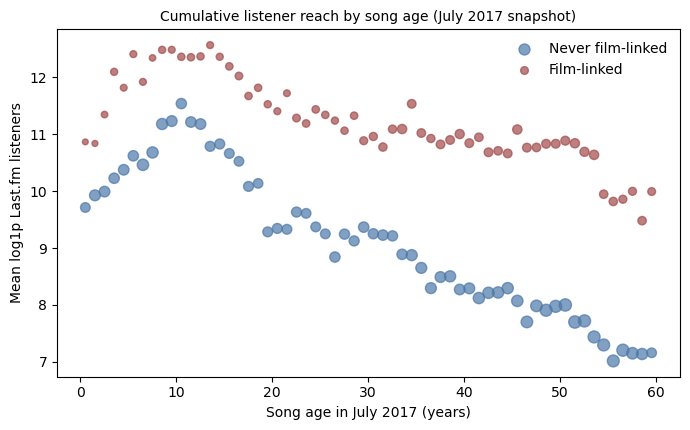

In [11]:
d = lastfm[lastfm["age"] >= 0].copy()
d["age_int"] = np.floor(d["age"]).astype(int)
prof = (
    d.groupby(["age_int", "film_linked"])
    .agg(mean_log1p_listeners=("attention", "mean"), sem=("attention", util.sem), n=("attention", "size"), age=("age", "mean"))
    .reset_index()
)
prof.to_csv(RESULTS / "lastfm_age_profile.csv", index=False)
bands = pd.DataFrame([
    {"age_band": "0-5 years", "mean_log1p_listeners": d[(d["age"] <= 5) & d["film_linked"].eq(0)]["attention"].mean()},
    {"age_band": "6-10 years", "mean_log1p_listeners": d[d["age"].between(6, 10) & d["film_linked"].eq(0)]["attention"].mean()},
    {"age_band": "20-40 years", "mean_log1p_listeners": d[d["age"].between(20, 40) & d["film_linked"].eq(0)]["attention"].mean()},
])
display(bands.round(3))
check(bands.iloc[1, 1] > bands.iloc[0, 1], "never-film Last.fm reach rises from ages 0-5 to 6-10 (not monotonically decaying)")

fig, ax = plt.subplots(figsize=(7.0, 4.4))
for linked, label, color in [(0, "Never film-linked", "#4C78A8"), (1, "Film-linked", "#A24B4B")]:
    g = prof[prof["film_linked"].eq(linked)]
    ax.scatter(g["age"], g["mean_log1p_listeners"], s=np.sqrt(g["n"]) * 4, alpha=0.7, color=color, label=label)
ax.set_xlabel("Song age in July 2017 (years)")
ax.set_ylabel("Mean log1p Last.fm listeners")
ax.legend(frameon=False)
ax.set_title("Cumulative listener reach by song age (July 2017 snapshot)", fontsize=10)
fig.tight_layout()
show_and_save_figure(fig, paths.OUT_FIG_SI / "figure_si_lastfm_age_profile.pdf")

## Paper artifacts for this section

Figure 4, the catalog SI tables, the catalog event-time SI figure, and the consolidated inference/robustness SI tables are generated here, from the result objects this notebook produces.

In [3]:
# Paper-artifact helpers: shared figure style, LaTeX writers, result-object reader.
from matplotlib.gridspec import GridSpec

from cdr import tex
from cdr.tex import fmt_num, fmt_int, fmt_p, fmt_ci
from cdr.util import (ACCENT, BLUE, CHARCOAL, COV_LABEL, DARK_BLUE, GRAY, GREEN, GRID,
                      LIGHT_BLUE, LIGHT_GRAY, SNAP_SHORT, errorbarh, errorbarv,
                      panel_label, set_plot_style)

set_plot_style()
R = lambda name: pd.read_csv(RESULTS / name, low_memory=False)

bin_of = {"pre (<= -2 years)": "<= -2", "event year": "0", "1-5 years post": "1 to 5", ">5 years post": ">5"}

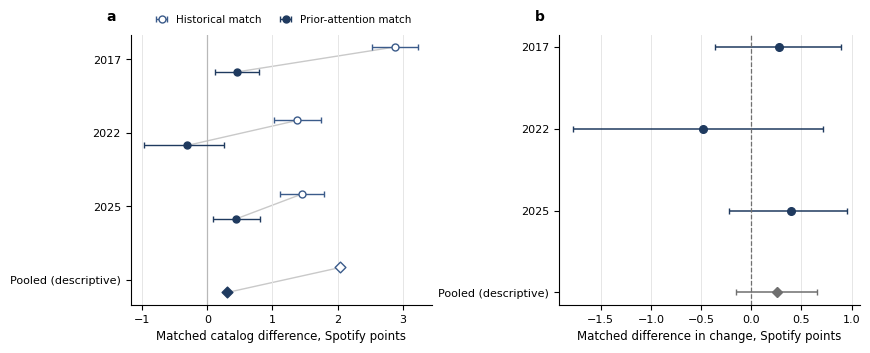

In [4]:
cmatch = R("catalog_matching_estimates.csv")
cinf_cat = R("catalog_matching_inference.csv")
cret = R("catalog_retention_by_cohort.csv").set_index("cohort")
cret_pool = R("catalog_retention_pooled.csv").iloc[0]

CAT_COHORTS = [("2017-07", "2017"), ("2022-08", "2022"), ("2025", "2025")]

def cat_row(design_start, snap):
    m = cmatch[(cmatch["platform"].eq("Spotify")) & (cmatch["design"].str.startswith(design_start)) & (cmatch["snapshot"].eq(snap))]
    return m.iloc[0]

def prior_interval(snap):
    r = cinf_cat[(cinf_cat["variant"].eq("with replacement")) & (cinf_cat["snapshot"].eq(snap))].iloc[0]
    return float(r["cluster_control_ci_low"]), float(r["cluster_control_ci_high"])

def plot_fig4_a(ax):
    rows = []
    for snap, short in CAT_COHORTS:
        h = cat_row("catalog historical", snap)
        p = cat_row("catalog baseline-attention", snap)
        plo, phi = prior_interval(snap)
        rows.append((short, float(h["estimate"]), float(h["conf_low"]), float(h["conf_high"]), float(p["estimate"]), plo, phi))
    y = np.arange(len(rows) + 1)
    off = 0.17
    for i, (label, he, hlo, hhi, pe, plo, phi) in enumerate(rows):
        ax.plot([he, pe], [y[i] - off, y[i] + off], color="#C9C9C9", lw=1.0, zorder=1)
        ax.errorbar([he], [y[i] - off], xerr=[[he - hlo], [hhi - he]], fmt="o", mfc="white", mec=BLUE,
                    color=BLUE, ecolor=BLUE, elinewidth=1.0, capsize=2.2, markersize=5, zorder=3,
                    label="Historical match" if i == 0 else None)
        ax.errorbar([pe], [y[i] + off], xerr=[[pe - plo], [phi - pe]], fmt="o", color=DARK_BLUE,
                    ecolor=DARK_BLUE, elinewidth=1.0, capsize=2.2, markersize=5, zorder=3,
                    label="Prior-attention match" if i == 0 else None)
    hp = cat_row("catalog historical", "pooled (inverse-variance)")
    pp = cat_row("catalog baseline-attention", "pooled (inverse-variance)")
    yp = len(rows)
    ax.plot([float(hp["estimate"]), float(pp["estimate"])], [yp - off, yp + off], color="#C9C9C9", lw=1.0, zorder=1)
    ax.scatter([float(hp["estimate"])], [yp - off], marker="D", facecolor="white", edgecolor=BLUE, s=30, zorder=3)
    ax.scatter([float(pp["estimate"])], [yp + off], marker="D", color=DARK_BLUE, s=30, zorder=3)
    ax.axvline(0, color=LIGHT_GRAY, lw=0.9)
    ax.set_yticks(y); ax.set_yticklabels([r[0] for r in rows] + ["Pooled (descriptive)"]); ax.invert_yaxis()
    ax.set_xlabel("Matched catalog difference, Spotify points", fontsize=8.5)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=7.5,
              columnspacing=1.3, handletextpad=0.4, borderaxespad=0.0)
    ax.grid(axis="x", color=GRID, lw=0.7)

def plot_fig4_b(ax):
    rows = []
    for snap, short in CAT_COHORTS:
        r = cret.loc[snap]
        rows.append((short, float(r["difference_in_change"]), float(r["primary_ci_low"]), float(r["primary_ci_high"]), DARK_BLUE, "o"))
    rows.append(("Pooled (descriptive)", float(cret_pool["difference_in_change"]), float(cret_pool["ci_low"]), float(cret_pool["ci_high"]), GRAY, "D"))
    y = np.arange(len(rows))
    for i, (label, e, lo, hi, color, marker) in enumerate(rows):
        ax.errorbar([e], [y[i]], xerr=[[e - lo], [hi - e]], fmt=marker, color=color, ecolor=color,
                    elinewidth=1.1, capsize=2.5, markersize=5.5)
    ax.axvline(0, color=GRAY, lw=0.9, ls="--")
    ax.set_yticks(y); ax.set_yticklabels([r[0] for r in rows]); ax.invert_yaxis()
    ax.set_xlabel("Matched difference in change, Spotify points", fontsize=8.5)
    ax.grid(axis="x", color=GRID, lw=0.7)

fig = plt.figure(figsize=(8.2, 3.7))
gs = GridSpec(1, 2, figure=fig, wspace=0.42, left=0.09, right=0.98, top=0.885, bottom=0.155)
ax_a = fig.add_subplot(gs[0, 0]); ax_b = fig.add_subplot(gs[0, 1])
plot_fig4_a(ax_a); plot_fig4_b(ax_b)
panel_label(ax_a, "a"); panel_label(ax_b, "b")
show_and_save_figure(fig, paths.OUT_FIG_MAIN / "figure4_artist_catalog_regimes.pdf")

**Static artist-catalog attention differences among non-film Billboard songs.** (`tab:si-catalog-static`)

,Platform,Snapshot,Estimate,95% CI,p,N obs.,Exposed,Control
0,Spotify,2016,2.32,"[1.81, 2.83]",<0.001,"10,966","6,858","4,108"
1,Spotify,2017,3.57,"[3.05, 4.09]",<0.001,"12,550","8,253","4,297"
2,Spotify,2022,2.08,"[1.59, 2.57]",<0.001,"15,487","9,356","6,131"
3,Spotify,2025,2.34,"[1.90, 2.79]",<0.001,"18,442","10,671","7,771"
4,Spotify,pooled,2.47,"[2.22, 2.72]",<0.001,"57,445","35,138","22,307"
5,Last.fm,2017,0.68,"[0.60, 0.75]",<0.001,"12,419","8,179","4,240"


**Dynamic artist-catalog event-time pattern among non-film songs.** (`tab:si-catalog-dynamic`)

,Event bin,Estimate,SE,95% CI,N exposed obs.,N songs,N artists
0,pre (<= -2 years),5.31,0.512,"[4.31, 6.32]",407,233,38
1,event year,5.09,0.741,"[3.64, 6.54]",211,210,43
2,1-5 years post,5.40,0.254,"[4.90, 5.90]","1,776","1,292",171
3,>5 years post,3.66,0.105,"[3.46, 3.87]","32,506","10,274","1,525"


**Matched artist-catalog attention premiums.** (`tab:si-catalog-matching`)

...

PASS: catalog balance table retains one row per balance record


**Covariate balance for the artist-catalog matched designs (long format).** (`tab:si-catalog-balance`)

,Platform,Design,Snapshot,Covariate,T mean,C mean,SMD,T mean,C mean,SMD
0,Spotify,Hist.,2016,Chart debut year,1983.17,1990.20,-0.391,1983.17,1983.19,-0.001
1,Spotify,Hist.,2016,Song age,33.63,26.60,0.391,33.63,33.61,0.001
2,Spotify,Hist.,2016,Billboard weeks,11.20,12.06,-0.108,11.20,11.14,0.009
3,Spotify,Hist.,2016,Peak chart position,44.97,47.38,-0.081,44.97,44.65,0.011
4,Spotify,Hist.,2016,Artist Billboard catalog size,20.49,10.01,0.451,20.49,18.55,0.121
...,...,...,...,...,...,...,...,...,...,...
71,Last.fm,Prior,2017,"Artist total Billboard weeks, excluding focal ...",222.90,75.23,0.958,222.90,194.95,0.162
72,Last.fm,Prior,2017,"Artist mean Billboard weeks, excluding focal song",12.22,10.74,0.270,12.22,12.18,0.007
73,Last.fm,Prior,2017,Artist best other-song peak position,6.93,26.47,-0.951,6.93,7.89,-0.082
74,Last.fm,Prior,2017,"Artist superstar indicator, top 1 percent",0.23,0.06,0.484,0.23,0.23,0.001


**Replacement-aware inference and design sensitivity for the matched catalog premium.** (`tab:si-catalog-matching-inference`)

,Comparison,Variant,Pairs,Unique controls,Estimate,Naive SE,Cluster SE (control),95% CI
0,catalog baseline-attention | 2017-07 (with rep...,with replacement,"6,794","1,927",0.46,0.087,0.174,"[0.11, 0.79]"
1,catalog baseline-attention | 2017-07 (no repla...,no replacement,"3,271","3,271",1.29,0.130,--,"[1.04, 1.55]"
2,catalog baseline-attention | 2017-07 (stricter...,stricter caliper,"6,794","2,019",0.26,0.081,--,"[0.10, 0.42]"
3,catalog baseline-attention | 2017-07 (CEM deca...,CEM,"6,794",--,1.57,--,--,--
4,catalog baseline-attention | 2022-08 (with rep...,with replacement,"7,712","2,197",-0.31,0.131,0.317,"[-0.97, 0.26]"
5,catalog baseline-attention | 2022-08 (no repla...,no replacement,"3,740","3,740",0.32,0.183,--,"[-0.04, 0.67]"
6,catalog baseline-attention | 2022-08 (stricter...,stricter caliper,"7,712","2,293",-0.35,0.127,--,"[-0.60, -0.10]"
7,catalog baseline-attention | 2022-08 (CEM deca...,CEM,"7,712",--,-0.70,--,--,--
8,catalog baseline-attention | 2025 (with replac...,with replacement,"9,285","3,049",0.44,0.091,0.184,"[0.09, 0.81]"
9,catalog baseline-attention | 2025 (no replacem...,no replacement,"5,268","5,265",1.02,0.124,--,"[0.78, 1.27]"


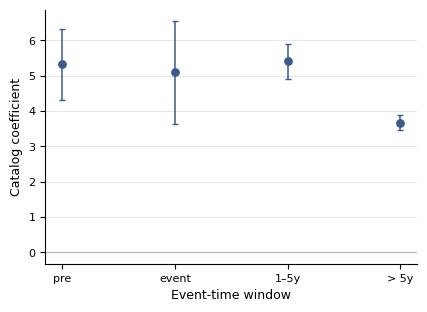

**Catalog attention changes on the fixed prior-attention matched pairs.** (`tab:si-catalog-retention`)

,Cohort,Pairs,Treated artists,Control artists,Treated change,Control change,Diff. in change,Primary 95% CI,Observed change pattern
0,July 2017,"6,794","1,293",802,4.63,4.36,0.27,"[-0.36, 0.89]",treated and controls both increased; treated i...
1,August 2022,"7,712","1,358",889,3.41,3.89,-0.48,"[-1.78, 0.71]",treated increased less than controls
2,August 2025,"9,285","1,485","1,053",0.03,-0.36,0.40,"[-0.22, 0.95]",treated remained approximately stable; control...
3,"Pooled (fixed-effect, descriptive)","23,791",--,--,--,--,0.25,"[-0.15, 0.66]",descriptive pooled interval includes zero


**Leave-one-cohort-out sensitivity of the pooled catalog attention-change summary.** (`tab:si-catalog-retention-loco`)

,Omitted cohort,Included cohorts,Pooled diff. in change,95% CI
0,July 2017,"August 2022, August 2025",0.24,"[-0.30, 0.77]"
1,August 2022,"July 2017, August 2025",0.34,"[-0.09, 0.76]"
2,August 2025,"July 2017, August 2022",0.12,"[-0.43, 0.68]"


In [5]:
# S: catalog static -- C21
cstat = R("catalog_static.csv")
rows = []
for _, r in cstat.iterrows():
    rows.append([r["platform"], SNAP_SHORT.get(r["snapshot"], r["snapshot"]), fmt_num(r["estimate"]), fmt_ci(r["conf_low"], r["conf_high"]), fmt_p(r["p_value"]), fmt_int(r["n_song_snapshots"]), fmt_int(r["n_exposed"]), fmt_int(r["n_control"])])
tex.write_table(paths.OUT_TABLES_SI / "table_si_catalog_static.tex",
    "Static artist-catalog attention differences among non-film Billboard songs.", "tab:si-catalog-static",
    ["Platform", "Snapshot", "Estimate", "95\\% CI", "$p$", "N obs.", "Exposed", "Control"],
    rows,
    note="Exposure: the same normalized artist/band string has another Billboard song linked to a film. Models adjust for song age, squared age, Billboard weeks, peak position, artist catalog size, artist total weeks excluding the focal song, best other-song peak, and superstar status; the pooled model adds snapshot fixed effects (HC1 intervals; the cluster-by-song variant appears in the SI inference table). Last.fm uses log1p cumulative listeners. Estimates describe adjusted attention differences across the observed artist groups.",
    size=r"\footnotesize", stretch=1.05, escape_cells=False)

# S: catalog dynamic -- C22
cdyn = R("catalog_dynamic.csv")
cds = R("catalog_dynamic_support.csv").set_index("catalog_event_bin")
rows = []
for _, r in cdyn.iterrows():
    b = bin_of[r["term"]]
    rows.append([r["term"], fmt_num(r["estimate"]), fmt_num(r["std_error"], 3), fmt_ci(r["conf_low"], r["conf_high"]), fmt_int(cds.loc[b, "n_song_snapshots"]), fmt_int(cds.loc[b, "n_songs"]), fmt_int(cds.loc[b, "n_artists"])])
tex.write_table(paths.OUT_TABLES_SI / "table_si_catalog_dynamic.tex",
    "Dynamic artist-catalog event-time pattern among non-film songs.", "tab:si-catalog-dynamic",
    ["Event bin", "Estimate", "SE", "95\\% CI", "N exposed obs.", "N songs", "N artists"],
    rows,
    note="Event time is relative to the first film appearance of any other Billboard song by the same artist; songs by artists with no film-linked song form the omitted reference with the immediate pre-year (66{,}838 observations; HC1 intervals). The positive pre-event estimate documents prior attention differences between groups, so this pattern does not isolate increases associated with placement. Only one Last.fm listener snapshot exists, so a Last.fm dynamic model is not estimated.",
    size=r"\footnotesize", stretch=1.05, escape_cells=False)

# S: catalog matching estimates -- C23
rows = []
for _, r in cmatch.iterrows():
    rows.append([r["platform"], ("Historical" if "historical" in r["design"] else "Prior-attention"), SNAP_SHORT.get(r["snapshot"], r["snapshot"]),
                 fmt_int(r.get("n_treated_available")), fmt_int(r.get("n_matched_treated")), fmt_int(r.get("n_unique_controls")),
                 fmt_num(r["estimate"]), fmt_ci(r["conf_low"], r["conf_high"]), fmt_num(r.get("max_abs_smd_after"), 3)])
tex.write_table(paths.OUT_TABLES_SI / "table_si_catalog_matching.tex",
    "Matched artist-catalog attention premiums.", "tab:si-catalog-matching",
    ["Platform", "Design", "Snapshot", r"\makecell[b]{Treated\\ available}", "Matched", r"\makecell[b]{Unique\\ controls}", "Estimate", "95\\% CI", r"\makecell[b]{Max\\ $|$SMD$|$\\ after}"],
    rows,
    note="Nearest-neighbor matching with replacement among non-film songs. Pooled rows aggregate per-snapshot matched differences by inverse variance (descriptive). Intervals use paired standard errors; replacement-aware inference is reported in the catalog matching-inference table, under which the August 2022 baseline-attention contrast is not robustly distinguishable from zero.",
    placement="H",
    col_spec=r">{\raggedright\arraybackslash}p{0.085\linewidth}>{\raggedright\arraybackslash}p{0.09\linewidth}>{\raggedright\arraybackslash}p{0.095\linewidth}>{\centering\arraybackslash}p{0.088\linewidth}>{\centering\arraybackslash}p{0.075\linewidth}>{\centering\arraybackslash}p{0.078\linewidth}>{\centering\arraybackslash}p{0.082\linewidth}>{\centering\arraybackslash}p{0.10\linewidth}>{\centering\arraybackslash}p{0.095\linewidth}",
    size=r"\footnotesize", stretch=1.05, tabcolsep="3pt", escape_cells=False)

# S: catalog balance (longtable) -- C23 balance
cbal = R("catalog_matching_balance_long.csv")
bal_rows = []
for _, r in cbal.iterrows():
    bal_rows.append([r["platform"], "Hist." if "historical" in r["design"] else "Prior", SNAP_SHORT.get(r["snapshot"], r["snapshot"]), COV_LABEL.get(r["covariate"], r["covariate"]),
                     fmt_num(r["treated_mean_before"]), fmt_num(r["control_mean_before"]), fmt_num(r["smd_before"], 3),
                     fmt_num(r["treated_mean_after"]), fmt_num(r["control_mean_after"]), fmt_num(r["smd_after"], 3)])
check(len(bal_rows) == len(cbal), "catalog balance table retains one row per balance record")
tex.write_longtable(paths.OUT_TABLES_SI / "table_si_catalog_balance.tex",
    "Covariate balance for the artist-catalog matched designs (long format).", "tab:si-catalog-balance",
    ["Platform", "Design", "Snapshot", "Covariate", "T mean", "C mean", "SMD", "T mean", "C mean", "SMD"],
    bal_rows,
    note="Hist.\\ = historical matching; Prior = prior-attention matching. Before columns compare all catalog-exposed with all unexposed non-film songs before matching; after columns compare matched samples. Artist catalogs vary strongly in historical visibility and size, which is why the full covariate-level balance is retained.",
    col_spec=r">{\raggedright\arraybackslash}p{0.078\linewidth}>{\raggedright\arraybackslash}p{0.075\linewidth}>{\raggedright\arraybackslash}p{0.08\linewidth}>{\raggedright\arraybackslash}p{0.185\linewidth}" + r">{\centering\arraybackslash}p{0.068\linewidth}" * 6,
    size=r"\footnotesize", group_header=[("", 1), ("", 1), ("", 1), ("", 1), ("Before matching", 3), ("After matching", 3)], stretch=1.05)

# S: catalog matching inference -- C23 reuse threat
cinf = R("catalog_matching_inference.csv")
rows = []
for _, r in cinf.iterrows():
    rows.append([r.get("comparison", ""), r.get("variant", ""), fmt_int(r.get("n_matched_pairs")), fmt_int(r.get("n_unique_controls")),
                 fmt_num(r.get("estimate")), fmt_num(r.get("naive_paired_se"), 3), fmt_num(r.get("cluster_control_se"), 3),
                 (fmt_ci(r.get("cluster_control_ci_low"), r.get("cluster_control_ci_high")) if pd.notna(r.get("cluster_control_ci_low")) else fmt_ci(r.get("naive_ci_low"), r.get("naive_ci_high")))])
tex.write_longtable(paths.OUT_TABLES_SI / "table_si_catalog_matching_inference.tex",
    "Replacement-aware inference and design sensitivity for the matched catalog premium.", "tab:si-catalog-matching-inference",
    ["Comparison", "Variant", "Pairs", r"\makecell[b]{Unique\\ controls}", "Estimate", r"\makecell[b]{Naive\\ SE}", r"\makecell[b]{Cluster\\ SE\\ (control)}", "95\\% CI"],
    rows,
    note="Catalog controls are reused heavily under matching with replacement, so cluster-by-control intervals are the primary uncertainty check for the prior-attention catalog premium; under this inference the August 2022 contrast is not robustly distinguishable from zero, while no-replacement, stricter-caliper, and coarsened-exact-matching variants return small positive premiums.",
    col_spec=r">{\raggedright\arraybackslash}p{0.19\linewidth}>{\raggedright\arraybackslash}p{0.17\linewidth}>{\centering\arraybackslash}p{0.052\linewidth}>{\centering\arraybackslash}p{0.078\linewidth}>{\centering\arraybackslash}p{0.082\linewidth}>{\centering\arraybackslash}p{0.052\linewidth}>{\centering\arraybackslash}p{0.082\linewidth}>{\centering\arraybackslash}p{0.105\linewidth}",
    size=r"\footnotesize", stretch=1.05, escape_cells=False)

# S: catalog event-time selection diagnostic -- C22 (moved from the previous main Figure 4)
cdyn_si = R("catalog_dynamic.csv").set_index("term")
fig, ax = plt.subplots(figsize=(4.8, 3.3))
order = ["pre (<= -2 years)", "event year", "1-5 years post", ">5 years post"]
labels = ["pre", "event", "1–5y", "> 5y"]
x = np.arange(4)
errorbarv(ax, x, cdyn_si.loc[order, "estimate"], cdyn_si.loc[order, "conf_low"], cdyn_si.loc[order, "conf_high"], color=BLUE, size=28)
ax.axhline(0, color=LIGHT_GRAY, lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Catalog coefficient"); ax.set_xlabel("Event-time window")
ax.grid(axis="y", color=GRID, lw=0.7)
show_and_save_figure(fig, paths.OUT_FIG_SI / "figure_si_catalog_event_time_selection.pdf")

# S: direct catalog-retention diagnostic -- C24
cret_t = R("catalog_retention_by_cohort.csv")
cpool_t = R("catalog_retention_pooled.csv").iloc[0]
cloco_t = R("catalog_retention_leave_one_cohort_out.csv")
OBSERVED_CHANGE_PATTERN = {
    "2017-07": "treated and controls both increased; treated increased slightly more",
    "2022-08": "treated increased less than controls",
    "2025": "treated remained approximately stable; controls declined",
}
rows = []
for _, r in cret_t.iterrows():
    rows.append([SNAPSHOT_LABEL[r["cohort"]], fmt_int(r["n_pairs"]), fmt_int(r["n_unique_treated_artists"]),
                 fmt_int(r["n_unique_control_artists"]), fmt_num(r["treated_change"]), fmt_num(r["control_change"]),
                 fmt_num(r["difference_in_change"]), fmt_ci(r["primary_ci_low"], r["primary_ci_high"]),
                 OBSERVED_CHANGE_PATTERN[r["cohort"]]])
rows.append(["Pooled (fixed-effect, descriptive)", fmt_int(cpool_t["n_pairs"]), "--", "--", "--", "--",
             fmt_num(cpool_t["difference_in_change"]), fmt_ci(cpool_t["ci_low"], cpool_t["ci_high"]),
             "descriptive pooled interval includes zero"])
tex.write_table(paths.OUT_TABLES_SI / "table_si_catalog_retention.tex",
    "Catalog attention changes on the fixed prior-attention matched pairs.", "tab:si-catalog-retention",
    ["Cohort", "Pairs", r"\makecell[b]{Treated\\ artists}", r"\makecell[b]{Control\\ artists}", r"\makecell[b]{Treated\\ change}", r"\makecell[b]{Control\\ change}", r"\makecell[b]{Diff.\ in\\ change}", r"\makecell[b]{Primary\\ 95\% CI}", "Observed change pattern"],
    rows,
    note="Prior-to-current change scores on the identical prior-attention matched catalog pairs; no rematching is performed. The primary interval is a two-way pigeonhole bootstrap over treated and reused control artist identities (2{,}000 deterministic-seed replications), because catalog exposure is defined at the artist level and pairs are dependent within artists on both sides. The pooled row is a descriptive inverse-variance combination of three heterogeneous cohorts and should not override the cohort-specific pattern. Pattern descriptions summarize observed group changes and are descriptive; the artist-level confidence intervals provide the inferential assessment.",
    col_spec=r">{\raggedright\arraybackslash}p{0.105\linewidth}>{\centering\arraybackslash}p{0.062\linewidth}" + r">{\centering\arraybackslash}p{0.072\linewidth}" * 5 + r">{\centering\arraybackslash}p{0.105\linewidth}>{\raggedright\arraybackslash}p{0.18\linewidth}",
    size=r"\footnotesize", stretch=1.10, tabcolsep="3pt", escape_cells=False)

# S: catalog-retention leave-one-cohort-out -- C24 sensitivity
rows = []
for _, r in cloco_t.iterrows():
    included = ", ".join(SNAPSHOT_LABEL[c.strip()] for c in r["included_cohorts"].split(","))
    rows.append([SNAPSHOT_LABEL[r["omitted_cohort"]], included, fmt_num(r["difference_in_change"]),
                 fmt_ci(r["ci_low"], r["ci_high"])])
tex.write_table(paths.OUT_TABLES_SI / "table_si_catalog_retention_loco.tex",
    "Leave-one-cohort-out sensitivity of the pooled catalog attention-change summary.", "tab:si-catalog-retention-loco",
    ["Omitted cohort", "Included cohorts", "Pooled diff.\ in change", "95\% CI"],
    rows,
    note="Each row recomputes the descriptive fixed-effect pooled difference-in-change after omitting one cohort, using the primary artist-level variances. With only three heterogeneous cohorts these are sensitivity descriptions, not formal heterogeneity tests.",
    size=r"\footnotesize", stretch=1.05, escape_cells=False)

In [6]:
# S: cluster-by-song inference (exact final specifications) -- C24
cl_rows = pd.concat([
    R("pooled_premium_cluster_rows.csv"),
    R("embedding_visibility_cluster_rows.csv"),
    R("robustness_cluster_rows.csv").iloc[[0]],
], ignore_index=True)
visibility_term_labels = {'log1p max worldwide box office realized by snapshot': 'log1p max recorded worldwide box office; films released by snapshot year'}
rows = []
for _, r in cl_rows.iterrows():
    rows.append([tex.tex_escape(r["model"]), tex.tex_escape(visibility_term_labels.get(str(r["term"]), str(r["term"])).replace("_", " ")) if pd.notna(r.get("term")) else "", fmt_int(r["n_observations"]), fmt_int(r["n_clusters"]),
                 fmt_num(r["estimate"]), fmt_num(r["hc1_se"], 3), fmt_num(r["cluster_se"], 3), fmt_ci(r["cluster_ci_low"], r["cluster_ci_high"]), fmt_p(r["cluster_p"])])
check(len(rows) == len(cl_rows), "cluster-inference table retains one row per refitted final specification")
tex.write_longtable(paths.OUT_TABLES_SI / "table_si_cluster_inference.tex",
    "Cluster-by-song inference for pooled models with repeated song-snapshot observations.", "tab:si-cluster-inference",
    ["Model", "Term", "N obs.", "N clusters", "Estimate", "SE", "SE", "95\\% CI", "$p$"],
    rows,
    note="Every row refits the exact final specification and exposure definition reported in the paper (time-respecting exposures where those are primary) and compares HC1 with cluster-by-song standard errors; clusters are Billboard song-artist records. These checks address repeated song-snapshot dependence; they do not alter the estimands.",
    col_spec=r">{\raggedright\arraybackslash}p{0.19\linewidth}>{\raggedright\arraybackslash}p{0.15\linewidth}>{\centering\arraybackslash}p{0.055\linewidth}>{\centering\arraybackslash}p{0.062\linewidth}>{\centering\arraybackslash}p{0.082\linewidth}>{\centering\arraybackslash}p{0.045\linewidth}>{\centering\arraybackslash}p{0.045\linewidth}>{\centering\arraybackslash}p{0.10\linewidth}>{\centering\arraybackslash}p{0.072\linewidth}",
    group_header=[("", 1), ("", 1), ("Support", 2), ("", 1), ("HC1", 1), ("Cluster-by-song inference", 3)],
    size=r"\footnotesize", stretch=1.05, escape_cells=False)

# S: robustness summary -- C25
rb = R("robustness_cluster_rows.csv").iloc[1:]
robustness_interpretation_labels = {
    "selection before observed film placement": "attention difference before observed film placement",
    "pooled premium is not driven by superstar songs": "positive association after excluding superstar songs",
    "catalog association is not an artifact of collaboration credit strings": "positive association after excluding collaboration-like strings",
}
rows = []
for _, r in rb.iterrows():
    rows.append([tex.tex_escape(r["model"]), tex.tex_escape(r["exposure_definition"]), fmt_num(r["estimate"]), fmt_num(r["cluster_se"], 3), fmt_ci(r["cluster_ci_low"], r["cluster_ci_high"]), fmt_p(r["cluster_p"]), fmt_int(r["n_observations"]), fmt_int(r["n_clusters"]), tex.tex_escape(robustness_interpretation_labels.get(r["interpretation"], r["interpretation"]))])
tex.write_table(paths.OUT_TABLES_SI / "table_si_robustness_summary.tex",
    "Robustness and placebo checks (exact final specifications, cluster-by-song inference).", "tab:si-robustness-summary",
    ["Check", "Exact specification", "Estimate", r"\makecell[b]{Cluster\\ SE}", "95\\% CI", "$p$", "N obs.", r"\makecell[b]{N\\ clusters}", "Interpretation"],
    rows,
    note="The future-placement placebo compares not-yet-film-linked song-snapshots with never-film songs; a positive value documents an attention difference before observed placement. The superstar exclusion refits the pooled broad premium without the top 1\\% of songs by Billboard weeks. The collaboration-string exclusion refits the exact final pooled catalog specification after removing collaboration-like artist strings, addressing catalog-key sensitivity.",
    col_spec=r">{\raggedright\arraybackslash}p{0.13\linewidth}>{\raggedright\arraybackslash}p{0.15\linewidth}>{\centering\arraybackslash}p{0.082\linewidth}>{\centering\arraybackslash}p{0.07\linewidth}>{\centering\arraybackslash}p{0.085\linewidth}>{\centering\arraybackslash}p{0.075\linewidth}>{\centering\arraybackslash}p{0.065\linewidth}>{\centering\arraybackslash}p{0.078\linewidth}>{\raggedright\arraybackslash}p{0.15\linewidth}",
    size=r"\footnotesize", stretch=1.10, tabcolsep="2.5pt", escape_cells=False)

PASS: cluster-inference table retains one row per refitted final specification


**Cluster-by-song inference for pooled models with repeated song-snapshot observations.** (`tab:si-cluster-inference`)

,Model,Term,N obs.,N clusters,Estimate,SE,SE,95% CI,p
0,Pooled broad Spotify film-linked premium,film linked,"83,785","28,281",13.79,0.128,0.227,"[13.35, 14.24]",<0.001
1,Pooled standardized Spotify film-linked premium,film linked,"83,785","28,281",0.66,0.006,0.011,"[0.63, 0.68]",<0.001
2,"Repeated embedding (time-respecting, primary)",1 realized films vs none,"83,780","28,281",9.25,0.153,0.264,"[8.73, 9.76]",<0.001
3,"Repeated embedding (time-respecting, primary)",2-3 realized films vs none,"83,780","28,281",16.72,0.203,0.341,"[16.05, 17.39]",<0.001
4,"Repeated embedding (time-respecting, primary)",4+ realized films vs none,"83,780","28,281",24.19,0.249,0.424,"[23.35, 25.02]",<0.001
5,"Film visibility (continuous, time-respecting, ...",log1p max recorded worldwide box office; films...,"15,245","4,294",1.15,0.058,0.102,"[0.95, 1.35]",<0.001
6,Song event-time model (broad),pre (<= -2 years),"83,785","28,281",9.50,0.671,0.865,"[7.80, 11.19]",<0.001
7,Song event-time model (broad),event year,"83,785","28,281",11.23,0.908,0.911,"[9.44, 13.02]",<0.001
8,Song event-time model (broad),1-5 years post,"83,785","28,281",10.16,0.357,0.436,"[9.31, 11.02]",<0.001
9,Song event-time model (broad),>5 years post,"83,785","28,281",14.18,0.136,0.239,"[13.71, 14.65]",<0.001


**Robustness and placebo checks (exact final specifications, cluster-by-song inference).** (`tab:si-robustness-summary`)

,Check,Exact specification,Estimate,Cluster SE,95% CI,p,N obs.,N clusters,Interpretation
0,Future-placement placebo,film-linked song observed before its first fil...,9.57,0.665,"[8.27, 10.88]",<0.001,"67,453","23,994",attention difference before observed film plac...
1,Superstar exclusion (pooled broad premium),ever film-linked; songs with >= 40 Billboard w...,13.95,0.230,"[13.50, 14.40]",<0.001,"83,002","27,999",positive association after excluding superstar...
2,Catalog premium excluding collaboration-like a...,artist has another film-linked Billboard song;...,3.21,0.223,"[2.78, 3.65]",<0.001,"52,967","17,155",positive association after excluding collabora...
